# J06 — Équation de Richards et solutions numériques

**Physique et hydrodynamique des sols** — S. J. Gumiere

*Atelier du Jour 6 : solveur de Richards (forme mixte, Picard, tridiagonal), vérification contre HYDRUS-1D, sensibilité, pluie avec ruissellement*

> Version **instructeur** : code complet et résultats.

## Mise en place

Conventions : $z$ positif vers le haut, origine en surface ; flux $q > 0$ vers le haut (infiltration négative), comme dans HYDRUS-1D.
Les fonctions hydrauliques de Mualem–van Genuchten sont fournies (elles acceptent un jeu de paramètres par nœud, utile pour les sols stratifiés du Jour 7).

In [1]:
import sys, time; sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded
from hydrus_io import read_tlevel, read_nod_inf, read_obs_node, read_balance, read_run_inf

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True, "grid.alpha": 0.3})
HYD = "../../hydrus"
LOAM = [0.078, 0.430, 0.036, 1.56, 24.96, 0.5]      # Carsel & Parrish : thr, ths, alpha, n, Ks (cm/j), l

# fonctions de Mualem–van Genuchten, vectorisées ; p = liste ou tableau (6, N) (un jeu de paramètres par nœud)
def vg_theta(h, p):
    thr, ths, a, n = p[0], p[1], p[2], p[3]; m = 1 - 1 / n
    h = np.asarray(h, float)
    Se = np.where(h < 0, (1 + (a * np.abs(h))**n)**(-m), 1.0)
    return thr + (ths - thr) * Se

def vg_K(h, p):
    thr, ths, a, n, Ks, l = p[0], p[1], p[2], p[3], p[4], p[5]; m = 1 - 1 / n
    h = np.asarray(h, float)
    Se = np.where(h < 0, (1 + (a * np.abs(h))**n)**(-m), 1.0)
    return Ks * Se**l * (1 - (1 - Se**(1 / m))**m)**2

def vg_C(h, p):
    thr, ths, a, n = p[0], p[1], p[2], p[3]; m = 1 - 1 / n
    h = np.asarray(h, float); ah = a * np.abs(h)
    return np.where(h < 0, (ths - thr) * a * n * m * ah**(n - 1) * (1 + ah**n)**(-m - 1), 0.0)

## Exercice 1 — Le solveur `richards_1d` : forme mixte, Picard modifié, système tridiagonal  *(≈ 25 min)*

Compléter la fonction `richards_1d` (les parties marquées `# À COMPLÉTER`) :

1. **Assemblage** du système tridiagonal d'une itération de Picard (nœuds intérieurs) :
   $a_i = -K_{i-1/2}/\Delta z^2$, $c_i = -K_{i+1/2}/\Delta z^2$, $b_i = C_i/\Delta t + (K_{i-1/2}+K_{i+1/2})/\Delta z^2$,
   $R_i = -(\theta_i^m - \theta_i^n)/\Delta t - (q_{i-1/2}^m - q_{i+1/2}^m)/\Delta z$ ;
   la demi-maille de surface avec flux imposé : $b_0 = C_0/\Delta t + 2K_{1/2}/\Delta z^2$, $c_0 = -2K_{1/2}/\Delta z^2$,
   $R_0 = -(\theta_0^m-\theta_0^n)/\Delta t - 2(q_{top} - q_{1/2}^m)/\Delta z$.
2. **Résolution** avec `scipy.linalg.solve_banded((1, 1), ab, R)` (format : `ab[0, 1:] = c[:-1]`, `ab[1] = b`, `ab[2, :-1] = a[1:]`).
3. **Contrôle du pas de temps** : $\times 1{,}3$ si $\le 3$ itérations, $\times 0{,}7$ si $\ge 7$, bornes `dt_min`/`dt_max`
   (la division par 3 en cas de non-convergence est déjà codée).

Puis simuler l'infiltration submergée dans le loam ($h_0 = -100$ cm, $h_{top} = 0$, drainage libre, $L = 100$ cm, $\Delta z = 1$ cm, 1 j),
tracer les profils $\theta(z)$ à 0,1 ; 0,25 ; 0,5 ; 0,75 ; 1 j et $I(t)$, et vérifier le bilan de masse (erreur relative $< 0{,}1$ %).
Attendu : $I(1\,\mathrm{j}) \approx 25{,}9$ cm, front au fond vers 0,7 j.

temps de calcul : 5.1 s
pas de temps : 5467, itérations : 24308, échecs : 8
infiltration cumulée I(1 j) = 25.886 cm ; drainage = 7.186 cm ; stock : 24.307 -> 43.000 cm ; erreur de bilan = -0.0072 cm (0.028 %)


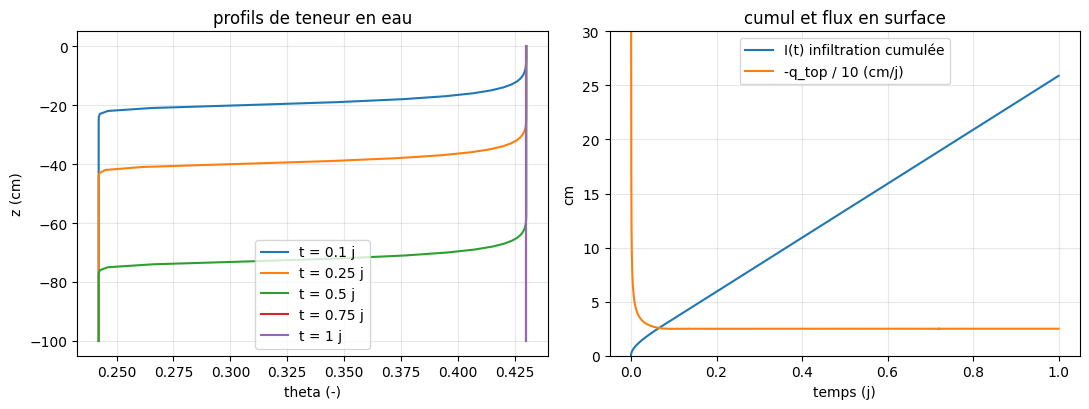

In [2]:
def richards_1d(sol, L=100.0, dz=1.0, h_init=-100.0, t_end=1.0, top=("head", 0.0), bot=("free",),
                dt0=1e-4, dt_min=1e-8, dt_max=0.02, tol=1e-5, maxit=30, kmean="arith",
                t_out=(), obs_z=(), hCritS=0.0):
    """Équation de Richards 1D, forme mixte (Celia et al. 1990), Picard modifié, Euler implicite, système tridiagonal.

    z positif vers le haut ; nœud 0 en surface (z = 0), nœud N au fond (z = -L) ; flux q > 0 vers le haut.
    sol : [thr, ths, alpha, n, Ks, l] (ou tableau (N+1, 6) : un jeu par nœud pour un sol stratifié).
    top : ("head", h) | ("flux", q) | ("atm", q_pot)  [atm : bascule vers h = hCritS en cas de submersion]
    bot : ("free",) | ("head", h) | ("flux", q)
    Critère de convergence : résidu de masse nodal |F| < tol (unités de theta) -> schéma conservatif.
    Retourne un dict : z, h, theta, hist (séries), prof (profils aux t_out), bilan.
    """
    N = int(round(L / dz)); z = -dz * np.arange(N + 1)
    P = np.array(sol, float); P = np.tile(P, (N + 1, 1)) if P.ndim == 1 else P
    P = P.T                                                    # (6, N+1) : un jeu de paramètres par nœud
    th_f, K_f, C_f = (lambda h: vg_theta(h, P)), (lambda h: vg_K(h, P)), (lambda h: vg_C(h, P))
    h = np.full(N + 1, float(h_init)) if np.ndim(h_init) == 0 else np.array(h_init, float)
    if top[0] == "head": h[0] = top[1]
    if bot[0] == "head": h[-1] = bot[1]
    obs_i = [int(round(-zz / dz)) for zz in obs_z]
    t_out = list(sorted(t_out))
    volume = lambda th: dz * (th.sum() - 0.5 * (th[0] + th[-1]))   # stock (cm), demi-mailles aux bords

    def k_inter(K, hm):
        """Conductivité inter-nodale (N valeurs) : arithmétique (HYDRUS), géométrique ou amont."""
        if kmean == "geom": return np.sqrt(K[:-1] * K[1:])
        if kmean == "amont":
            H = hm + z; return np.where(H[:-1] >= H[1:], K[:-1], K[1:])
        return 0.5 * (K[:-1] + K[1:])

    def fluxes(hm):
        """Flux inter-nodaux q_{i+1/2} = -K_{i+1/2} ((h_i - h_{i+1})/dz + 1), positifs vers le haut."""
        K = K_f(hm); Kh = k_inter(K, hm)
        return K, Kh, -Kh * ((hm[:-1] - hm[1:]) / dz + 1.0)

    def residu(hm, th_old, dt, mode, val):
        """Résidu de masse de chaque nœud (en unités de theta) pour le candidat hm."""
        K, Kh, q = fluxes(hm); th = th_f(hm)
        F = (th - th_old) + (dt / dz) * np.r_[0.0, q[:-1] - q[1:], 0.0]
        F[0] = 0.0 if mode == "head" else (th[0] - th_old[0]) + (2 * dt / dz) * (val - q[0])
        qb = -K[-1] if bot[0] == "free" else (bot[1] if bot[0] == "flux" else 0.0)
        F[-1] = 0.0 if bot[0] == "head" else (th[-1] - th_old[-1]) + (2 * dt / dz) * (q[-1] - qb)
        return F, q, K

    def picard(h_old, th_old, dt, mode, val):
        """Un pas de temps par itérations de Picard modifiées ; mode = 'head' (h[0] = val) ou 'flux' (q_top = val)."""
        hm = h_old.copy()
        if mode == "head": hm[0] = val
        ab = np.zeros((3, N + 1)); omega = 1.0; d_prev = None
        for it in range(1, maxit + 1):
            th_m, Cm = th_f(hm), C_f(hm)
            K, Kh, q = fluxes(hm)
            # --- assemblage du système tridiagonal a_i d_{i-1} + b_i d_i + c_i d_{i+1} = R_i (nœuds intérieurs)
            a = -np.r_[0.0, Kh] / dz**2                          # sous-diagonale (K_{i-1/2})
            c = -np.r_[Kh, 0.0] / dz**2                          # sur-diagonale  (K_{i+1/2})
            b = Cm / dt + (np.r_[0.0, Kh] + np.r_[Kh, 0.0]) / dz**2
            R = -(th_m - th_old) / dt                            # résidu du stockage (forme mixte)
            R[1:-1] -= (q[:-1] - q[1:]) / dz                     # divergence des flux à l'itéré m
            # --- limite supérieure (demi-maille)
            if mode == "head":
                a[0], b[0], c[0], R[0] = 0.0, 1.0, 0.0, 0.0      # delta_0 = 0 (h imposé)
            else:
                b[0] = Cm[0] / dt + 2 * Kh[0] / dz**2; c[0] = -2 * Kh[0] / dz**2
                R[0] -= (val - q[0]) / (dz / 2)                  # flux q_top imposé
            # --- limite inférieure (demi-maille)
            if bot[0] == "head":
                a[-1], b[-1], c[-1], R[-1] = 0.0, 1.0, 0.0, 0.0
            else:
                qb = -K[-1] if bot[0] == "free" else bot[1]      # drainage libre : q = -K(h_N)
                b[-1] = Cm[-1] / dt + 2 * Kh[-1] / dz**2; a[-1] = -2 * Kh[-1] / dz**2
                R[-1] -= (q[-1] - qb) / (dz / 2)
            # --- résolution (algorithme de Thomas)
            ab[0, 1:] = c[:-1]; ab[1] = b; ab[2, :-1] = a[1:]
            delta = solve_banded((1, 1), ab, R)
            # --- sous-relaxation si oscillation (changement de signe de delta au nœud le plus actif)
            if d_prev is not None:
                j = np.argmax(np.abs(delta))
                if delta[j] * d_prev[j] < 0 and abs(delta[j]) > 0.5 * abs(d_prev[j]): omega = 0.5
            d_prev = delta
            hm = hm + omega * delta
            if mode == "head": hm[0] = val
            if bot[0] == "head": hm[-1] = bot[1]
            # --- convergence : résidu de masse nodal
            F, q, K = residu(hm, th_old, dt, mode, val)
            if np.max(np.abs(F)) < tol:
                return hm, it, True, q, K
        return hm, maxit, False, None, None

    # ------------------------------------------------------------------ boucle en temps
    t, dt = 0.0, dt0
    th_n = th_f(h); W0 = volume(th_n)
    hist = {k: [] for k in ("t", "qtop", "qbot", "I", "runoff", "htop", "iter", "dt", "obs_h", "obs_th")}
    def log(qt, qb, it):
        for k, v in zip(hist, (t, qt, qb, I_cum, R_cum, h[0], it, dt, h[obs_i].copy(), th_n[obs_i].copy())):
            hist[k].append(v)
    I_cum = R_cum = 0.0; log(np.nan, np.nan, 0)
    prof, k_out, n_fail = {}, 0, 0
    while t < t_end - 1e-12:
        dt = min(dt, t_end - t)
        if k_out < len(t_out) and t + dt > t_out[k_out] - 1e-12: dt = t_out[k_out] - t   # pas forcé
        while True:                                                # tentatives avec réduction de dt
            mode, val = ("head", top[1]) if top[0] == "head" else ("flux", top[1])
            h_new, it, ok, q, K = picard(h, th_n, dt, mode, val)
            if ok and top[0] == "atm" and h_new[0] > hCritS:       # submersion : on impose h = hCritS
                mode, val = "head", hCritS
                h_new, it, ok, q, K = picard(h, th_n, dt, mode, val)
            if ok: break
            dt /= 3; n_fail += 1
            if dt < dt_min: raise RuntimeError(f"pas de temps < dt_min à t = {t:.4g}")
        # --- pas accepté : flux aux limites (conservatifs), cumuls
        h = h_new; th_new = th_f(h)
        qtop = val if mode == "flux" else q[0] - (dz / 2) * (th_new[0] - th_n[0]) / dt
        qbot = bot[1] if bot[0] == "flux" else (-K[-1] if bot[0] == "free" else q[-1] + (dz / 2) * (th_new[-1] - th_n[-1]) / dt)
        t += dt; th_n = th_new
        I_cum += -qtop * dt
        if top[0] == "atm" and mode == "head": R_cum += max(0.0, qtop - top[1]) * dt   # pluie non infiltrée
        log(qtop, qbot, it)
        if k_out < len(t_out) and abs(t - t_out[k_out]) < 1e-9:
            prof[t_out[k_out]] = (h.copy(), th_n.copy()); k_out += 1
        # --- contrôle du pas de temps (règles HYDRUS)
        if it <= 3: dt = min(dt * 1.3, dt_max)
        elif it >= 7: dt = max(dt * 0.7, dt_min)
    hist = {k: np.array(v) for k, v in hist.items()}
    W = volume(th_n); tt = hist["t"]
    D_cum = -np.sum(hist["qbot"][1:] * np.diff(tt))                # drainage cumulé (positif vers le bas)
    bilan = dict(W0=W0, W=W, dW=W - W0, infiltration=I_cum, drainage=D_cum, ruissellement=R_cum,
                 erreur=W - W0 - (I_cum - D_cum), n_pas=len(tt) - 1, n_iter=int(hist["iter"].sum()), n_echecs=n_fail)
    bilan["erreur_rel_%"] = 100 * abs(bilan["erreur"]) / max(abs(I_cum), abs(D_cum), 1e-12)
    return dict(z=z, h=h, theta=th_n, hist=hist, prof=prof, bilan=bilan)

# ---- infiltration submergée dans le loam : h0 = -100 cm, h_top = 0, drainage libre, 100 cm, 1 j
t_print = [0.1, 0.25, 0.5, 0.75, 1.0]
t0 = time.time()
res = richards_1d(LOAM, L=100, dz=1.0, h_init=-100.0, t_end=1.0, top=("head", 0.0), bot=("free",),
                  t_out=t_print, obs_z=[-10, -30, -50])
print(f"temps de calcul : {time.time() - t0:.1f} s")
b = res["bilan"]
print(f"pas de temps : {b['n_pas']}, itérations : {b['n_iter']}, échecs : {b['n_echecs']}")
print(f"infiltration cumulée I(1 j) = {b['infiltration']:.3f} cm ; drainage = {b['drainage']:.3f} cm ; "
      f"stock : {b['W0']:.3f} -> {b['W']:.3f} cm ; erreur de bilan = {b['erreur']:.4f} cm ({b['erreur_rel_%']:.3f} %)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for t in t_print:
    hh, th = res["prof"][t]
    ax[0].plot(th, res["z"], label=f"t = {t:g} j")
ax[0].set(xlabel="theta (-)", ylabel="z (cm)", title="profils de teneur en eau"); ax[0].legend()
ax[1].plot(res["hist"]["t"], res["hist"]["I"], label="I(t) infiltration cumulée")
ax[1].plot(res["hist"]["t"], -res["hist"]["qtop"] / 10, label="-q_top / 10 (cm/j)")
ax[1].set(xlabel="temps (j)", ylabel="cm", title="cumul et flux en surface", ylim=(0, 30)); ax[1].legend()
plt.tight_layout(); plt.show()

**Commentaire (instructeur).** Le solveur reproduit le comportement attendu : flux initial très grand (contraste $h = 0$ / $h = -100$ sur 1 cm), puis $-q_{top} \to K_s$
lorsque le profil se sature ; le front atteint le fond vers 0,7 j et le drainage démarre. L'erreur de bilan est de l'ordre de
$10^{-2}$ % grâce au critère de convergence sur le résidu de masse : la forme mixte n'est conservative qu'à convergence, et
l'itération de Picard stagne près de la saturation ($n < 2$) sans la sous-relaxation.

## Exercice 2 — Vérification contre HYDRUS-1D  *(≈ 15 min)*

Projet `J06_infiltration_submergee_loam` (mêmes conditions que l'exercice 1).

1. `read_nod_inf` : superposer les profils $\theta(z)$ et $h(z)$ HYDRUS (temps d'impression 0,1 ; 0,25 ; 0,5 j) aux profils du solveur
   et calculer l'écart RMS sur $\theta$ et sur $h$ à chaque temps.
2. `read_obs_node` : $\theta(t)$ et $h(t)$ aux nœuds 10, 30, 50 cm (HYDRUS vs solveur, `hist["obs_th"]`) ; temps d'arrivée du front
   à chaque profondeur (premier instant où $\theta > 0{,}35$).
3. `read_tlevel` : $I(t)$ = `sum(Infil)` vs solveur ; `Volume`, `sum(vBot)` à 1 j vs le bilan du solveur ; `read_balance` : `WatBalR`.

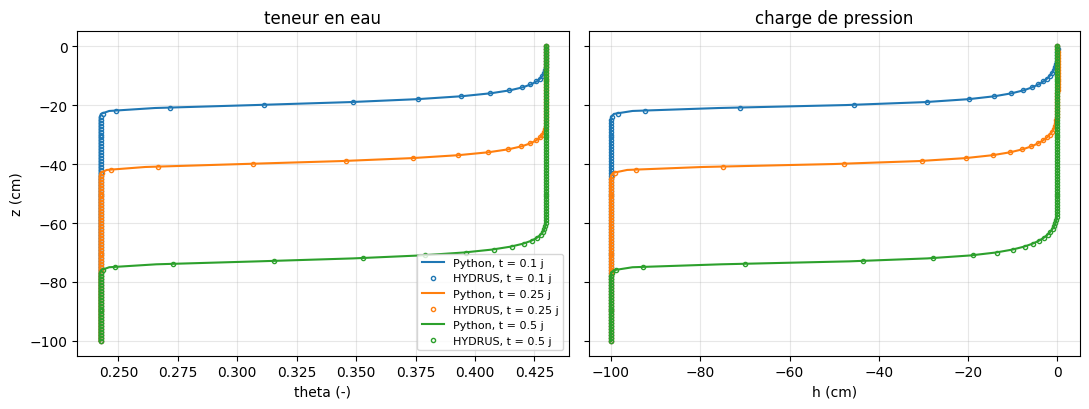

,t,RMS_theta,RMS_h_cm,front_python_cm,front_hydrus_cm
0,0.10,0.0009,0.5915,-19.0,-19.0
1,0.25,0.0008,0.5537,-39.0,-39.0
2,0.50,0.0011,0.6837,-72.0,-73.0


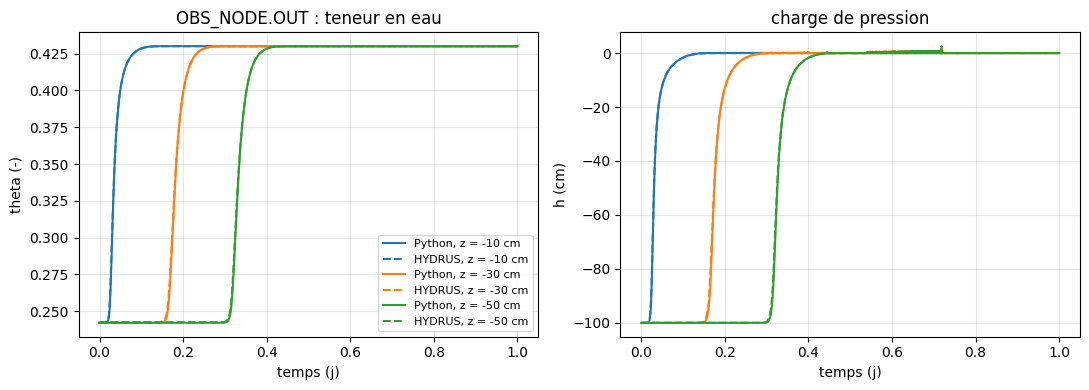

,profondeur_cm,t_arrivee_python_j,t_arrivee_hydrus_j,vitesse_front_cm_j
0,10,0.0363,0.0363,275.4821
1,30,0.1836,0.1837,163.3097
2,50,0.3345,0.3343,149.5663


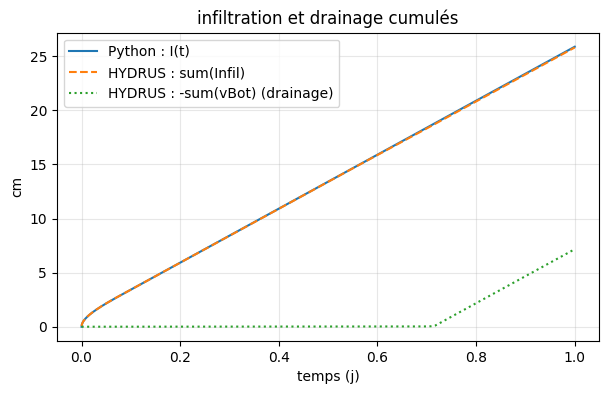

,Python,HYDRUS
infiltration cumulée (cm),25.886,25.816
drainage cumulé (cm),7.186,7.167
stock initial (cm),24.307,24.351
stock final (cm),43.000,43.000
erreur de bilan (%),0.028,0.000


écart relatif sur I(1 j) : +0.27 %


In [3]:
P = f"{HYD}/J06_infiltration_submergee_loam"
nod = read_nod_inf(P); ob = read_obs_node(P); tl = read_tlevel(P); bal = read_balance(P)

# 1. profils
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
rows = []
for t in [0.1, 0.25, 0.5]:
    hh, th = res["prof"][t]; d = nod[t]
    l, = ax[0].plot(th, res["z"], label=f"Python, t = {t:g} j")
    ax[0].plot(d["Moisture"], d["Depth"], "o", ms=3, mfc="none", color=l.get_color(), label=f"HYDRUS, t = {t:g} j")
    ax[1].plot(hh, res["z"], color=l.get_color()); ax[1].plot(d["Head"], d["Depth"], "o", ms=3, mfc="none", color=l.get_color())
    rows.append(dict(t=t, RMS_theta=np.sqrt(np.mean((th - d["Moisture"].to_numpy())**2)),
                     RMS_h_cm=np.sqrt(np.mean((hh - d["Head"].to_numpy())**2)),
                     front_python_cm=res["z"][np.argmax(th < 0.35)], front_hydrus_cm=d["Depth"].to_numpy()[np.argmax(d["Moisture"].to_numpy() < 0.35)]))
ax[0].set(xlabel="theta (-)", ylabel="z (cm)", title="teneur en eau"); ax[0].legend(fontsize=8)
ax[1].set(xlabel="h (cm)", title="charge de pression")
plt.tight_layout(); plt.show()
display(pd.DataFrame(rows).round(4))

# 2. nœuds d'observation
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
arr = []
for k, (nd, zz) in enumerate(zip([11, 31, 51], [10, 30, 50])):
    l, = ax[0].plot(res["hist"]["t"], res["hist"]["obs_th"][:, k], label=f"Python, z = -{zz} cm")
    ax[0].plot(ob.index, ob[(nd, "theta")], "--", color=l.get_color(), label=f"HYDRUS, z = -{zz} cm")
    ax[1].plot(res["hist"]["t"], res["hist"]["obs_h"][:, k], color=l.get_color()); ax[1].plot(ob.index, ob[(nd, "h")], "--", color=l.get_color())
    t_py = res["hist"]["t"][np.argmax(res["hist"]["obs_th"][:, k] > 0.35)]
    t_hy = ob.index[np.argmax(ob[(nd, "theta")].to_numpy() > 0.35)]
    arr.append(dict(profondeur_cm=zz, t_arrivee_python_j=t_py, t_arrivee_hydrus_j=t_hy, vitesse_front_cm_j=zz / t_hy))
ax[0].set(xlabel="temps (j)", ylabel="theta (-)", title="OBS_NODE.OUT : teneur en eau"); ax[0].legend(fontsize=8)
ax[1].set(xlabel="temps (j)", ylabel="h (cm)", title="charge de pression")
plt.tight_layout(); plt.show()
display(pd.DataFrame(arr).round(4))

# 3. cumuls et bilans
fig, ax = plt.subplots()
ax.plot(res["hist"]["t"], res["hist"]["I"], label="Python : I(t)")
ax.plot(tl.index, tl["sum(Infil)"], "--", label="HYDRUS : sum(Infil)")
ax.plot(tl.index, -tl["sum(vBot)"], ":", label="HYDRUS : -sum(vBot) (drainage)")
ax.set(xlabel="temps (j)", ylabel="cm", title="infiltration et drainage cumulés"); ax.legend(); plt.show()
b = res["bilan"]
comp = pd.DataFrame({"Python": [b["infiltration"], b["drainage"], b["W0"], b["W"], b["erreur_rel_%"]],
                     "HYDRUS": [tl["sum(Infil)"].iloc[-1], -tl["sum(vBot)"].iloc[-1], bal["W-volume"].iloc[0], tl["Volume"].iloc[-1], bal["WatBalR"].abs().max()]},
                    index=["infiltration cumulée (cm)", "drainage cumulé (cm)", "stock initial (cm)", "stock final (cm)", "erreur de bilan (%)"])
display(comp.round(3))
print(f"écart relatif sur I(1 j) : {100 * (b['infiltration'] / tl['sum(Infil)'].iloc[-1] - 1):+.2f} %")

**Commentaire (instructeur).** Les deux codes coïncident à mieux que 0,3 % sur l'infiltration cumulée et à $\theta < 0{,}003$ RMS sur les profils : même
équation, même discrétisation (éléments finis linéaires à masse condensée = différences finies), même moyenne arithmétique de $K$.
Les petits écarts de position du front (1 cm) viennent des tolérances et de la table d'interpolation d'HYDRUS. La vitesse moyenne
du front décroît de 275 cm/j (10 cm) à 150 cm/j (50 cm) et tend vers $K_s/\Delta\theta = 133$ cm/j (vitesse « piston ») : la
succion au front accélère le début de l'infiltration. C'est une *vérification* du solveur ; la *validation* demanderait des mesures.

## Exercice 3 — Sensibilité numérique : maillage, pas de temps, moyenne de K  *(≈ 15 min)*

Relancer `richards_1d` (infiltration submergée, 1 j) en faisant varier :

1. le pas d'espace $\Delta z$ = 0,5 ; 1 ; 2 ; 5 cm ;
2. le pas de temps maximal `dt_max` = 0,001 ; 0,01 ; 0,1 j (avec $\Delta z$ = 1 cm) ;
3. la moyenne inter-nodale de $K$ : `kmean` = `"arith"`, `"geom"`, `"amont"` (avec $\Delta z$ = 2 cm).

Tableau : $I(1\,\mathrm{j})$, position du front à 0,25 j (premier nœud où $\theta < 0{,}35$), nombre de pas, itérations totales,
erreur de bilan, temps de calcul. Tracer les profils $\theta(z)$ à 0,25 j pour les quatre maillages avec le profil HYDRUS.
Conclure : le résultat converge-t-il en maillage ? Quel paramètre domine l'erreur ?

,I_1j,front_025j_cm,n_pas,n_iter,erreur_bilan_cm,temps_s
cas,,,,,,
dz = 0.5 cm,25.8815,-39.0,9999,47309,-0.0513,12.0246
dz = 1 cm,25.8863,-39.0,5437,24011,-0.0051,5.0342
dz = 2 cm,25.9011,-40.0,2368,10813,0.0000,2.1408
dz = 5 cm,25.9185,-45.0,1022,3953,0.0021,0.9749
dt_max = 0.001 j,25.8863,-39.0,5695,24269,-0.0051,5.1695
dt_max = 0.01 j,25.8863,-39.0,5449,24023,-0.0051,5.0298
dt_max = 0.1 j,25.8863,-39.0,5432,24006,-0.0051,5.0286
K arith (dz = 2 cm),25.9011,-40.0,2368,10813,0.0000,2.2007
K geom (dz = 2 cm),25.6404,-38.0,2841,13439,-0.0043,2.7286


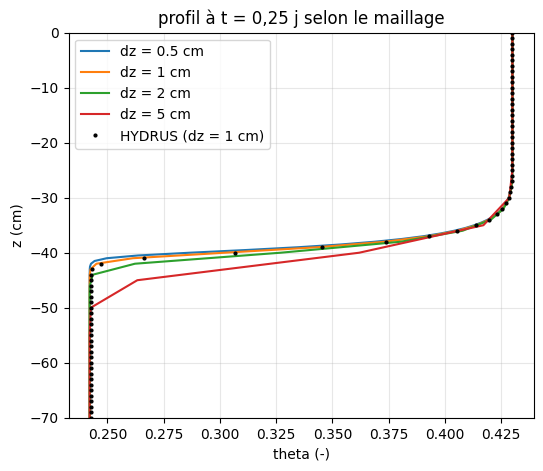

In [4]:
def run(**kw):
    t0 = time.time()
    r = richards_1d(LOAM, t_out=[0.25, 1.0], **kw)
    hh, th = r["prof"][0.25]
    return dict(I_1j=r["hist"]["I"][-1], front_025j_cm=r["z"][np.argmax(th < 0.35)], n_pas=r["bilan"]["n_pas"],
                n_iter=r["bilan"]["n_iter"], erreur_bilan_cm=r["bilan"]["erreur"], temps_s=time.time() - t0), r

rows, profils = [], {}
for dz in [0.5, 1.0, 2.0, 5.0]:
    d, r = run(dz=dz); rows.append(dict(cas=f"dz = {dz:g} cm", **d)); profils[dz] = r
for dtm in [0.001, 0.01, 0.1]:
    d, r = run(dt_max=dtm); rows.append(dict(cas=f"dt_max = {dtm:g} j", **d))
for km in ["arith", "geom", "amont"]:
    d, r = run(dz=2.0, kmean=km); rows.append(dict(cas=f"K {km} (dz = 2 cm)", **d))
tab = pd.DataFrame(rows).set_index("cas")
display(tab.round(4))

d025 = nod[0.25]
fig, ax = plt.subplots(figsize=(6, 5))
for dz, r in profils.items():
    ax.plot(r["prof"][0.25][1], r["z"], label=f"dz = {dz:g} cm")
ax.plot(d025["Moisture"], d025["Depth"], "k.", ms=4, label="HYDRUS (dz = 1 cm)")
ax.set(xlabel="theta (-)", ylabel="z (cm)", ylim=(-70, 0), title="profil à t = 0,25 j selon le maillage"); ax.legend(); plt.show()

**Commentaire (instructeur).** Le cumul $I(1\,\mathrm{j})$ varie de moins de 0,2 % quel que soit $\Delta z$ (la colonne finit saturée : le cumul est fixé par
$\theta_s$ et par $K_s$), mais le front à 0,25 j est nettement étalé et décalé de 6 cm sur le maillage à 5 cm (diffusion numérique).
`dt_max` n'a aucun effet ici : le contrôle par le nombre d'itérations impose $\Delta t \sim 10^{-4}$–$10^{-3}$ j tant que le front
traverse la colonne. La moyenne amont accélère le front (+1,7 % sur $I$), la géométrique le ralentit (−1 %) ; à $\Delta z \to 0$
les trois convergent. Le temps de calcul croît à peu près
comme le nombre de nœuds fois le nombre de pas.

## Exercice 4 — Pluie de 30 cm/j sur un loam sec : bascule de la condition atmosphérique  *(≈ 10 min)*

Projet `J06_pluie_flux_impose_loam` : pluie de 30 cm/j ($> K_s = 24{,}96$ cm/j) pendant 0,5 j puis 0, condition atmosphérique
avec ruissellement (`hCritS` = 0), $h_0 = -300$ cm, drainage libre.

1. Lire `T_LEVEL.OUT` et tracer `rTop` (flux potentiel), `vTop` (flux réel), `hTop`, `RunOff` et `sum(Infil)` en fonction du temps.
2. Déterminer le temps de submersion $t_p$ (premier instant où `hTop` $\ge 0$), l'infiltration cumulée à $t_p$, le ruissellement
   total et le coefficient de ruissellement (ruissellement / pluie).
3. Comparer $t_p$ à la prédiction de Green–Ampt / Mein–Larson (préview du Jour 7) : $I_p = K_s |h_f| \Delta\theta/(i - K_s)$,
   $t_p = I_p/i$, avec $|h_f| = \lambda_c = 6{,}9$ cm, $\Delta\theta = \theta_s - \theta(-300)$, $i = 30$ cm/j. Commenter l'écart.

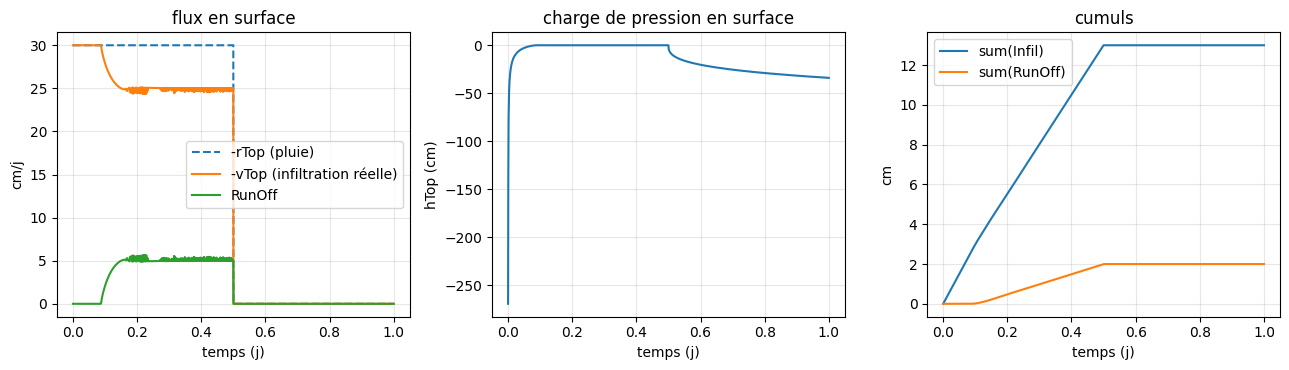

temps de submersion HYDRUS t_p = 0.0880 j = 127 min ; infiltration à t_p = 2.64 cm
pluie = 15.0 cm ; infiltrée = 13.00 cm ; ruisselée = 2.00 cm ; coefficient de ruissellement = 0.133
flux réel après submersion : vTop -> -24.89 cm/j (Ks = 24.96)
Green–Ampt : dtheta = 0.260, I_p = 8.91 cm, t_p = 0.297 j  (HYDRUS : 2.64 cm, 0.088 j)


In [5]:
P2 = f"{HYD}/J06_pluie_flux_impose_loam"
tl2 = read_tlevel(P2)
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
ax[0].plot(tl2.index, -tl2["rTop"], "--", label="-rTop (pluie)"); ax[0].plot(tl2.index, -tl2["vTop"], label="-vTop (infiltration réelle)")
ax[0].plot(tl2.index, tl2["RunOff"], label="RunOff"); ax[0].set(xlabel="temps (j)", ylabel="cm/j", title="flux en surface"); ax[0].legend()
ax[1].plot(tl2.index, tl2["hTop"]); ax[1].set(xlabel="temps (j)", ylabel="hTop (cm)", title="charge de pression en surface")
ax[2].plot(tl2.index, tl2["sum(Infil)"], label="sum(Infil)"); ax[2].plot(tl2.index, tl2["sum(RunOff)"], label="sum(RunOff)")
ax[2].set(xlabel="temps (j)", ylabel="cm", title="cumuls"); ax[2].legend()
plt.tight_layout(); plt.show()

tp = tl2.index[np.argmax(tl2["hTop"].to_numpy() >= -1e-6)]
I_tp = tl2["sum(Infil)"].loc[tp]
pluie = 30 * 0.5; ruiss = tl2["sum(RunOff)"].iloc[-1]; infil = tl2["sum(Infil)"].iloc[-1]
print(f"temps de submersion HYDRUS t_p = {tp:.4f} j = {tp * 24 * 60:.0f} min ; infiltration à t_p = {I_tp:.2f} cm")
print(f"pluie = {pluie:.1f} cm ; infiltrée = {infil:.2f} cm ; ruisselée = {ruiss:.2f} cm ; coefficient de ruissellement = {ruiss / pluie:.3f}")
print(f"flux réel après submersion : vTop -> {tl2['vTop'][(tl2.index > 0.3) & (tl2.index < 0.5)].mean():.2f} cm/j (Ks = {LOAM[4]})")

# 3. Green–Ampt / Mein–Larson avec h_f = lambda_c
Ks, i = LOAM[4], 30.0
lam_c = 6.92; dtheta = LOAM[1] - float(vg_theta(-300.0, LOAM))
I_p = Ks * lam_c * dtheta / (i - Ks); t_p_GA = I_p / i
print(f"Green–Ampt : dtheta = {dtheta:.3f}, I_p = {I_p:.2f} cm, t_p = {t_p_GA:.3f} j  (HYDRUS : {I_tp:.2f} cm, {tp:.3f} j)")

**Commentaire (instructeur).** Tant que la capacité d'infiltration dépasse 30 cm/j, HYDRUS impose le flux (`vTop` = `rTop`) et $h$ en surface monte de −300 à 0 cm
en 0,088 j (2 h) ; ensuite la condition bascule en charge imposée ($h = 0$), `vTop` tend vers $-K_s$ et l'excédent (5 cm/j) ruisselle :
2,0 cm sur 15 cm de pluie (coefficient 0,13). Green–Ampt avec $h_f = \lambda_c$ prévoit une submersion trois fois plus tardive
(0,30 j) : avec $i/K_s = 1{,}2$ seulement, $t_p$ est extrêmement sensible à la forme du front ; le front réel (MvG, $n = 1{,}56$) est
diffus et la succion effective au front est bien inférieure à $\lambda_c$ (voir Jour 7).

## Exercice 5 — Bonus — condition atmosphérique dans le solveur  *(≈ facultatif)*

Le solveur accepte `top=("atm", q_pot)` : il résout le pas avec le flux potentiel, puis, si $h_0 > $ `hCritS`, recommence avec
$h_0 = $ `hCritS` (charge imposée) et compte le ruissellement. Simuler la pluie de 30 cm/j pendant 0,5 j sur le loam à $h_0 = -300$ cm
(`dt_max = 0.01`), puis la redistribution sans pluie de 0,5 à 1 j (`top=("atm", 0.0)`, condition initiale = profil à 0,5 j) et
comparer $t_p$, `vTop`, le ruissellement cumulé et `hTop` à 1 j avec HYDRUS.

temps de calcul : 6.0 s
t_p Python = 0.0868 j (HYDRUS 0.0880) ; ruissellement Python = 1.99 cm (HYDRUS 2.00) ; infiltration Python = 13.01 cm (HYDRUS 13.00)
hTop à 1 j : Python -33.8 cm, HYDRUS -33.9 cm ; erreurs de bilan : -0.0005, -0.0003 cm


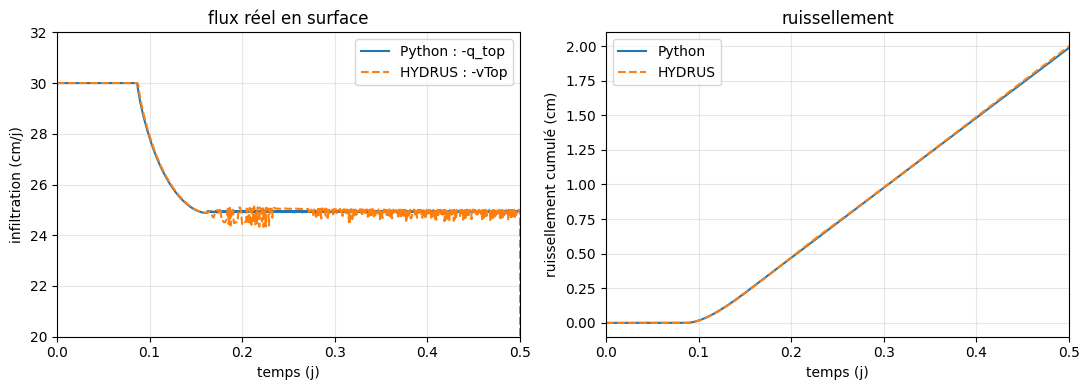

In [6]:
t0 = time.time()
r1 = richards_1d(LOAM, h_init=-300.0, t_end=0.5, top=("atm", -30.0), dt_max=0.01, t_out=[0.5])
r2 = richards_1d(LOAM, h_init=r1["h"], t_end=0.5, top=("atm", 0.0), dt_max=0.01, t_out=[0.5])
print(f"temps de calcul : {time.time() - t0:.1f} s")
tp_py = r1["hist"]["t"][np.argmax(r1["hist"]["htop"] >= -1e-9)]
print(f"t_p Python = {tp_py:.4f} j (HYDRUS {tp:.4f}) ; ruissellement Python = {r1['bilan']['ruissellement']:.2f} cm (HYDRUS {ruiss:.2f}) ; "
      f"infiltration Python = {r1['bilan']['infiltration']:.2f} cm (HYDRUS {infil:.2f})")
print(f"hTop à 1 j : Python {r2['h'][0]:.1f} cm, HYDRUS {tl2['hTop'].iloc[-1]:.1f} cm ; erreurs de bilan : {r1['bilan']['erreur']:.4f}, {r2['bilan']['erreur']:.4f} cm")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(r1["hist"]["t"], -r1["hist"]["qtop"], label="Python : -q_top")
ax[0].plot(tl2.index, -tl2["vTop"], "--", label="HYDRUS : -vTop")
ax[0].set(xlabel="temps (j)", ylabel="infiltration (cm/j)", xlim=(0, 0.5), ylim=(20, 32), title="flux réel en surface"); ax[0].legend()
ax[1].plot(r1["hist"]["t"], r1["hist"]["runoff"], label="Python"); ax[1].plot(tl2.index, tl2["sum(RunOff)"], "--", label="HYDRUS")
ax[1].set(xlabel="temps (j)", ylabel="ruissellement cumulé (cm)", xlim=(0, 0.5), title="ruissellement"); ax[1].legend()
plt.tight_layout(); plt.show()

**Commentaire (instructeur).** La bascule flux → charge est reproduite à 1 % près sur $t_p$ (0,087 j contre 0,088 j) et sur le ruissellement (1,99 contre 2,00 cm) :
la logique de HYDRUS tient en quelques lignes une fois le solveur en place. La redistribution après la pluie ramène $h$ en surface
à −34 cm à 1 j dans les deux codes.

## Pour aller plus loin

* Remplacer la moyenne arithmétique par une moyenne pondérée par la distance pour un maillage irrégulier (raffiné en surface).
* Ajouter la bascule vers `hCritA` (évaporation limitée par le sol) : symétrique de la submersion.
* Comparer le solveur à la solution de Philip (Jour 7) pour l'infiltration horizontale (sans gravité : retirer le « +1 » du gradient).